In [1]:
from innolux import *
project_data_path = data_path / "T1 6212 重啟" / "元件確認"


In [3]:
raw_df = pl.read_excel(project_data_path / "RTIS_STD元件確認_20260123.xlsx")

In [23]:
raw_df

panel,position,position order,channel,point,value
i64,str,i64,str,str,f64
11,"""中心""",1,"""Y""","""X""",2.3612
11,"""中心""",1,"""Y""","""Y""",2.6985
11,"""中心""",1,"""N""","""X""",1.5179
11,"""中心""",1,"""N""","""Y""",1.6866
11,"""中心""",2,"""Y""","""X""",1.6866
…,…,…,…,…,…
21,"""左下""",6,"""N""","""Y""",1.3493
21,"""右下""",7,"""Y""","""X""",2.0239
21,"""右下""",7,"""Y""","""Y""",2.0239


In [7]:
plot_df = (
    raw_df
    .group_by(
        ['panel', 'position', 'position order', 'channel']
    )
    .sum()
)

In [8]:
plot_df

panel,position,position order,channel,point,value
i64,str,i64,str,str,f64
21,"""右下""",7,"""N""",null,2.6985
11,"""中心""",2,"""Y""",null,3.7105
11,"""中心""",1,"""Y""",null,5.0597
21,"""左上""",4,"""Y""",null,4.3851
11,"""右下""",7,"""N""",null,3.2045
…,…,…,…,…,…
11,"""左上""",4,"""Y""",null,4.7224
21,"""左上""",4,"""N""",null,2.3612
11,"""左下""",6,"""Y""",null,4.7354


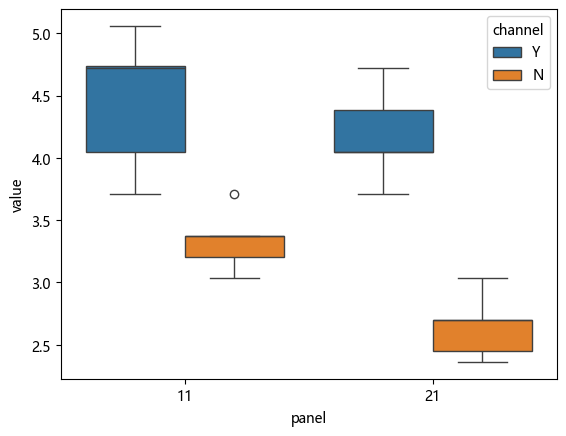

In [9]:
ax = sns.boxplot(
    plot_df,
    x='panel',
    y='value',
    hue='channel'
)

In [78]:
raw_df.group_by(["channel", "point"]).mean().group_by('channel').sum()

channel,point,panel,position,position order,value
str,str,f64,str,f64,f64
"""N""",null,32.0,null,8.0,2.975607
"""Y""",null,32.0,null,8.0,4.314671


In [79]:
2.975+4.315


7.290000000000001

Text(1.5, 2.02, 'Non-Channel LSL')

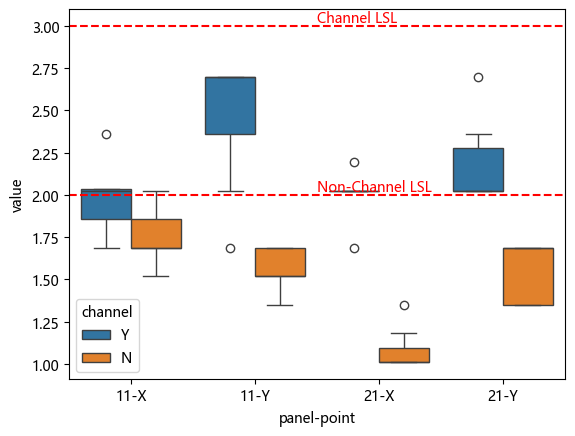

In [47]:
plot_df = (
    raw_df
    .with_columns(
        (pl.col('panel').cast(str) + '-' + pl.col('point'))
            .alias('panel-point')
    )
)

ax = sns.boxplot(
    plot_df,
    x='panel-point',
    y='value',
    hue='channel'
)

ax.axhline(3.0, color='r', linestyle='--')
ax.text(1.5, 3.02, color='r', s="Channel LSL")

ax.axhline(2.0, color='r', linestyle='--')
ax.text(1.5, 2.02, color='r', s="Non-Channel LSL")

In [65]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

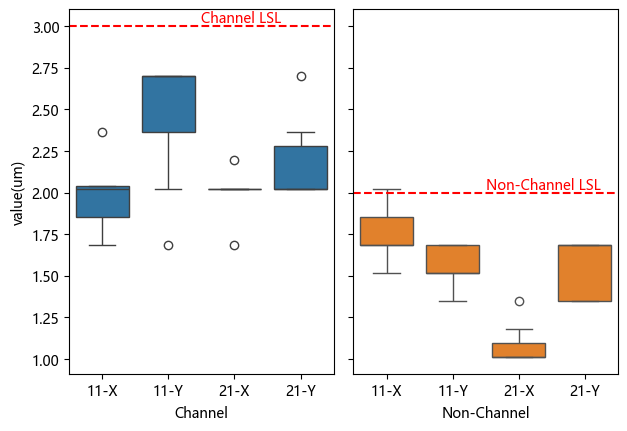

In [76]:
fig, axs = plt.subplots(1,2,sharey=True)
sns.boxplot(
    plot_df.filter(pl.col('channel')=='Y'),
    x='panel-point',
    y='value',
    ax=axs[0],
    # hue='point'
)
axs[0].set_ylabel('value(um)')
axs[0].set_xlabel('Channel')
axs[0].axhline(3.0, color='r', linestyle='--')
axs[0].text(1.5, 3.02, color='r', s="Channel LSL")

sns.boxplot(
    plot_df.filter(pl.col('channel')=='N'),
    x='panel-point',
    y='value',
    ax=axs[1],
    # hue='point',
    color=sns.color_palette()[1],
)
axs[1].set_xlabel('Non-Channel')

axs[1].axhline(2.0, color='r', linestyle='--')
axs[1].text(1.5, 2.02, color='r', s="Non-Channel LSL")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [49]:
plot_df

panel,position,position order,channel,point,value,panel-point
i64,str,i64,str,str,f64,str
11,"""中心""",1,"""Y""","""X""",2.3612,"""11-X"""
11,"""中心""",1,"""Y""","""Y""",2.6985,"""11-Y"""
11,"""中心""",1,"""N""","""X""",1.5179,"""11-X"""
11,"""中心""",1,"""N""","""Y""",1.6866,"""11-Y"""
11,"""中心""",2,"""Y""","""X""",1.6866,"""11-X"""
…,…,…,…,…,…,…
21,"""左下""",6,"""N""","""Y""",1.3493,"""21-Y"""
21,"""右下""",7,"""Y""","""X""",2.0239,"""21-X"""
21,"""右下""",7,"""Y""","""Y""",2.0239,"""21-Y"""


In [12]:
window_raw_df = pl.read_excel(project_data_path / "HTIS_其它window條件.xlsx")


In [13]:
window_raw_df

條件,RA,panel,channel,point,value
str,str,str,str,str,f64
"""LC to CHB 540 s""","""NG""","""624A1AO745M019A15""","""Y""","""X""",2.73
"""LC to CHB 540 s""","""NG""","""624A1AO745M019A15""","""N""","""X""",2.19
"""LC to CHB 540 s""","""NG""","""624A1AO745M019A15""","""Y""","""Y""",3.01
"""LC to CHB 540 s""","""NG""","""624A1AO745M019A15""","""N""","""Y""",1.92
"""LC to CHB 540 s""","""OK""","""624A1AO745M019C3F""","""Y""","""X""",2.74
…,…,…,…,…,…
"""SEUV7000""","""NG""","""624A1AO745M005D74""","""N""","""Y""",1.92
"""SEUV7000""","""OK""","""624A1AO745M005F7F""","""Y""","""X""",2.87
"""SEUV7000""","""OK""","""624A1AO745M005F7F""","""N""","""X""",2.05


In [14]:
plot_df = (
    window_raw_df
    .group_by(
        ['條件', 'RA', 'channel']
    )
    .sum()
)

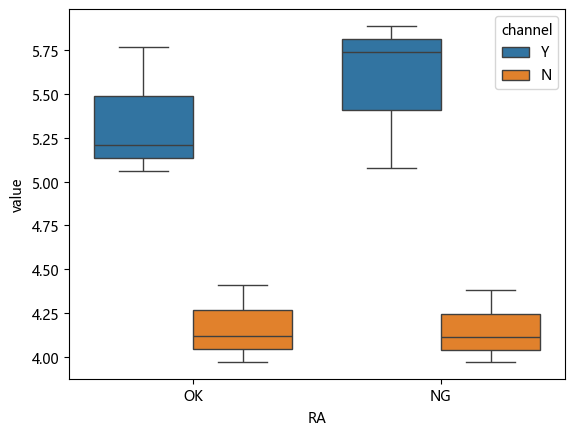

In [20]:
ax = sns.boxplot(
    plot_df.sort('channel', descending=True),
    x='RA',
    y='value',
    hue='channel'
)